In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
pip install kaggle

Defaulting to user installation because normal site-packages is not writeable

   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   ---------------------------------------- 3/3 [kaggle]

Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [01:17<00:00, 31.7MB/s]

Extracting files...


Path to dataset files: C:\Users\joaop\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [5]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Updated import
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau
import cv2
import os
import numpy as np

In [11]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 224
def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
               
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size)) 
                    if resized_arr is not None:  # Check if resize was successful
                        data.append([resized_arr, class_num])
                    else:
                         print(f"Warning: Could not resize image {img}")
                else:
                    print(f"Warning: Could not read image {img}")
            except Exception as e:
                print(f"Error loading image {img}: {e}")
    return np.array(data, dtype=object)

In [14]:
# Paths for each set
train_dir = r"C:\Users\joaop\OneDrive\Desktop\Pos_Grad_IA\gitluis\pos-grad-projects\artificial_neural_networking\chest_xray\train"
# Load datasets
train_data = get_training_data(train_dir)


In [15]:
X = np.array([i[0] for i in train_data]).astype("float32") / 255.0
y = np.array([i[1] for i in train_data])

# Split into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [16]:
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (3651, 224, 224, 3) (3651,)
Validation shape: (782, 224, 224, 3) (782,)
Test shape: (783, 224, 224, 3) (783,)


In [17]:
# Count samples per class
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(labels, counts))

print("Number of samples per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Number of samples per class:
PNEUMONIA: 2712
NORMAL: 939


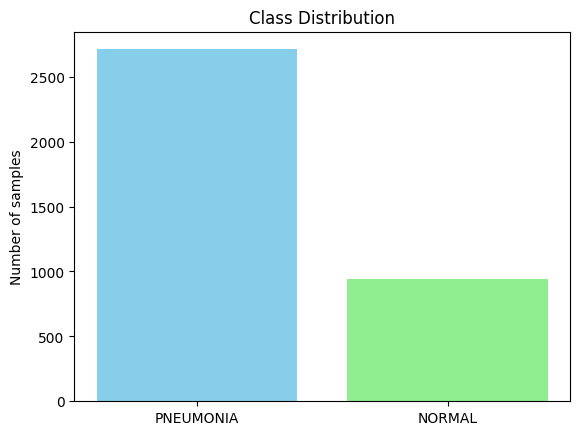

In [18]:
plt.bar(class_counts.keys(), class_counts.values(), color=['skyblue', 'lightgreen'])
plt.title("Class Distribution")
plt.ylabel("Number of samples")
plt.show()

In [19]:
normal_indices = np.where(y_train == 1)[0]
normal_images = X_train[normal_indices]
normal_labels = y_train[normal_indices]

In [20]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [21]:
augmented_images = []
augmented_labels = []

for img in normal_images:
    img = np.expand_dims(img, 0)  # datagen expects shape (1, H, W, C)
    for batch in datagen.flow(img, batch_size=1):
        augmented_images.append(batch[0])
        augmented_labels.append(1)  # NORMAL label
        break  # only 1 augmented copy per original

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Augmented set:", augmented_images.shape, augmented_labels.shape)


Augmented set: (939, 224, 224, 3) (939,)


In [22]:
X_train = X_train.astype('float16')

In [23]:
X_train_aug = np.concatenate((X_train, augmented_images), axis=0)
y_train_aug = np.concatenate((y_train, augmented_labels), axis=0)

print("New training set shape:", X_train_aug.shape, y_train_aug.shape)


New training set shape: (4590, 224, 224, 3) (4590,)


In [24]:
# Count samples per class
unique, counts = np.unique(y_train_aug, return_counts=True)
class_counts = dict(zip(labels, counts))

print("Number of samples per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Number of samples per class:
PNEUMONIA: 2712
NORMAL: 1878


In [25]:
BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_aug, y_train_aug))
    .shuffle(1000)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [26]:
def build_mini_vgg(input_shape=(224, 224, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

model = build_mini_vgg(input_shape=(224, 224, 3))


C:\Users\joaop\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,977,633 (99.10 MB)

 Trainable params: 25,977,633 (99.10 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    # Stop training if val_loss doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Save the best model (based on validation loss)
    ModelCheckpoint(
        filepath="best_model.keras",   
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate when val_loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,         # reduce LR by half
        patience=3,         # wait 3 epochs before reducing
        min_lr=1e-6,
        verbose=1
    )
]


In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks= callbacks
)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7574 - loss: 0.5195
Epoch 1: val_loss improved from None to 0.41013, saving model to best_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.7991 - loss: 0.4482 - val_accuracy: 0.8056 - val_loss: 0.4101 - learning_rate: 1.0000e-04
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8507 - loss: 0.3462
Epoch 2: val_loss improved from 0.41013 to 0.29265, saving model to best_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.8815 - loss: 0.2936 - val_accuracy: 0.8542 - val_loss: 0.2927 - learning_rate: 1.0000e-04
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9103 - loss: 0.2326

MemoryError: Unable to allocate 98.0 MiB for an array with shape (100352, 256) and data type float32

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step


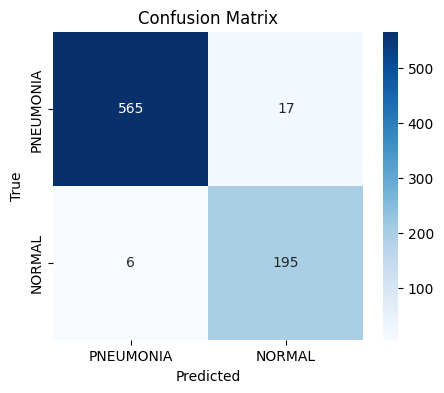

              precision    recall  f1-score   support

   PNEUMONIA       0.99      0.97      0.98       582
      NORMAL       0.92      0.97      0.94       201

    accuracy                           0.97       783
   macro avg       0.95      0.97      0.96       783
weighted avg       0.97      0.97      0.97       783



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Predict
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")  

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['PNEUMONIA', 'NORMAL'], 
            yticklabels=['PNEUMONIA', 'NORMAL'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 4. Classification Report
print(classification_report(y_test, y_pred, target_names=['PNEUMONIA', 'NORMAL']))


In [ ]:
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # unwrap the inner Sequential
    conv_base = model.get_layer("sequential")

    grad_model = tf.keras.models.Model(
        [conv_base.inputs],
        [conv_base.get_layer(last_conv_layer_name).output, conv_base.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalize between 0 and 1
    heatmap = np.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()


In [ ]:
def get_last_conv_layer(model):
    # Iterate through the model's layers in reverse order
    for layer in reversed(model.layers):
        # Check if the layer is a Conv2D instance
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer
    # If no Conv2D layer is found, raise an error
    raise ValueError("No Conv2D layer found in the model.")
last_conv_layer = get_last_conv_layer(model)
last_conv_layer = get_last_conv_layer(model)
print("The last convolutional layer is:", last_conv_layer.name)    

The last convolutional layer is: conv2d_5


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Pass a dummy tensor to build the model
    dummy_input = tf.random.normal((1, 224, 224, 3))
    _ = model(dummy_input)
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.layers[-1].output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

In [ ]:
dummy_input = tf.random.normal((1, 224, 224, 3))
_ = model(dummy_input)

output_tensor = model.layers[-1].output


In [ ]:
output_tensor

<KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=keras_tensor_16>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


model.load_weights("/kaggle/working/best_model.keras") # Load pre-trained weights if you have them

# 1. Get the last convolutional layer's name
last_conv_layer = get_last_conv_layer(model)
last_conv_layer_name = last_conv_layer.name


In [ ]:
# 2. Preprocess the image for the model
img_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1502_bacteria_3925.jpeg'
img_size = (224, 224)
img = tf.keras.utils.load_img(img_path, target_size=img_size)
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add a batch dimension

# 3. Generate the Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [ ]:
from matplotlib import cm
def display_gradcam(img_path, heatmap, alpha=0.4, display_size=(400, 400)):
    # Load the original image
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img = tf.keras.utils.img_to_array(img)
    
    # Ensure the original image is in the correct format and range
    img = np.uint8(img)
    
    # Resize the heatmap to the original image size
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps["jet"] # Use the new method
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Combine the heatmap with the original image
    superimposed_img = np.uint8(jet_heatmap * alpha + img)

    # Resize the superimposed image for display
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    superimposed_img = superimposed_img.resize(display_size)
    
    # Display the superimposed image
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

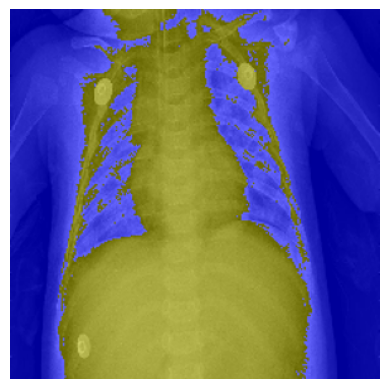

In [ ]:
# Example of how to call it:
display_gradcam(img_path, heatmap, alpha=0.6, display_size=(300, 300)) 